# Training pipeline with callbacks

- `VQCClassifier` trained with `EarlyStopping` and `ModelCheckpoint`.
- Both run on both backends, unlike a Lightning callback.
- Inspect what each callback recorded after training, then reload the checkpoint.
- Pennylane backend throughout.

### 1. Data

- `make_moons`, 200 samples.
- `normalize="minmax"`, fit on train only.
- `AngleEmbedding` prescaling maps it to [0, pi] in `setup()`.

In [1]:
from sklearn.datasets import make_moons

import pyqit
from pyqit import DataModule, Trainer
from pyqit.ansatzes import SELAnsatz
from pyqit.core import AngleEmbedding, EarlyStopping, ModelCheckpoint
from pyqit.models import VQCClassifier

pyqit.set_seed(42)

X, y = make_moons(n_samples=200, noise=0.1, random_state=0)
dm = DataModule(X, y, normalize="minmax", batch_size=16, seed=42)

### 2. Trainer with both callbacks

- `EarlyStopping` on `val_loss`, patience 5. Stops once it stops improving.
- `ModelCheckpoint` saves the best and last epoch, restores best weights after training.
- Kept as named variables, not inlined, to read their state after `fit`.
- `loss_fn="cross_entropy"`.

In [2]:
model = VQCClassifier(n_qubits=4, n_layers=3, ansatz=SELAnsatz, encoder=AngleEmbedding)

early_stop = EarlyStopping(monitor="val_loss", patience=5)
checkpoint = ModelCheckpoint(dirpath="ckpts", save_best=True, save_last=True)

trainer = Trainer(
    max_epochs=60,
    loss_fn="cross_entropy",
    callbacks=[early_stop, checkpoint],
    verbose=1,
)
history = trainer.fit(model, dm)

[Trainer] Starting pennylane backend | 60 epochs | lr=0.01

Output()

[EarlyStopping] Stopped at epoch 53 -- val_loss did not improve for 5 epoch(s) (best val_loss: 0.3214)

[Checkpoint] Last epoch -> ckpts/last.npz

[Checkpoint] Restored best weights from epoch 48 (val_loss: 0.3214)

[Trainer] Training complete.

### 3. What each callback recorded

- `early_stop.stopped_epoch` and `early_stop.stopping_reason`, set once training stops early.
- `checkpoint.best_epoch`, `checkpoint.best_path`, `checkpoint.last_path`, the epoch and files `ModelCheckpoint` wrote.
- `history.best_epoch`, `history.best_score`, `history.best_metric`, the same best epoch from the run's own record.

In [3]:
print("stopped at:", early_stop.stopped_epoch, "|", early_stop.stopping_reason)
print("best checkpoint:", checkpoint.best_epoch, "->", checkpoint.best_path)
print("last checkpoint:", checkpoint.last_path)
print("history best:", history.best_epoch, history.best_score, history.best_metric)

stopped at: 53 | val_loss did not improve for 5 epoch(s) (best val_loss: 0.3214)
best checkpoint: 48 -> ckpts/best.npz
last checkpoint: ckpts/last.npz
history best: 48 0.3213906665687111 val_loss


### 4. Loss curve

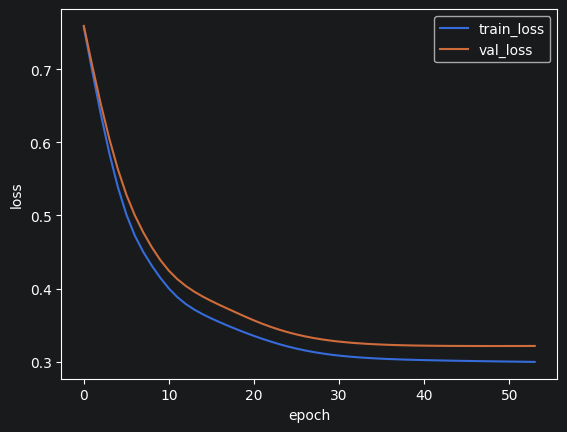

In [4]:
import matplotlib.pyplot as plt

plt.plot(history.train_loss, label="train_loss")
plt.plot(history.val_loss, label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

### 5. Reloading the checkpoint

- `.npz` on the pennylane backend, keyed by `model.weights` keys.
- `checkpoint.best_path` names the exact file `ModelCheckpoint` wrote.
- Load it into a fresh model and confirm it matches the weights `restore_best` already put back into `model`.

In [5]:
import numpy as np

saved = dict(np.load(checkpoint.best_path))

fresh_model = VQCClassifier(
    n_qubits=4, n_layers=3, ansatz=SELAnsatz, encoder=AngleEmbedding
)
fresh_model.update_weights(saved)

for key in model.weights:
    assert np.allclose(model.weights[key], fresh_model.weights[key])

print("checkpoint matches restored weights")

checkpoint matches restored weights
